# Cars 4 You: Expediting Car Evaluations with ML

## 1. Data Import & Exploratory Data Analysis



#### **1.1. Importing the Libraries and Dataset**


In [874]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [875]:
train= pd.read_csv("train.csv").copy() #importing the dataset
test=pd.read_csv("test.csv").copy()


#### **1.2. Initial Analysis**

In [876]:
#numero de linhas e colunas
print(train.shape) 

(75973, 14)


In [877]:
display(train.head())

,carID,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
0,69512,VW,Golf,2016.0,22290,Semi-Auto,28421.0,Petrol,NaN,11.417268,2.0,63.0,4.000000,0.0
1,53000,Toyota,Yaris,2019.0,13790,Manual,4589.0,Petrol,145.0,47.900000,1.5,50.0,1.000000,0.0
2,6366,Audi,Q2,2019.0,24990,Semi-Auto,3624.0,Petrol,145.0,40.900000,1.5,56.0,4.000000,0.0
3,29021,Ford,FIESTA,2018.0,12500,anual,9102.0,Petrol,145.0,65.700000,1.0,50.0,-2.340306,0.0
4,10062,BMW,2 Series,2019.0,22995,Manual,1000.0,Petrol,145.0,42.800000,1.5,97.0,3.000000,0.0


In [878]:
display(train.info()) # to see the data types and non-null values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 75973 entries, 0 to 75972
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   carID           75973 non-null  int64  
 1   Brand           74452 non-null  object 
 2   model           74456 non-null  object 
 3   year            74482 non-null  float64
 4   price           75973 non-null  int64  
 5   transmission    74451 non-null  object 
 6   mileage         74510 non-null  float64
 7   fuelType        74462 non-null  object 
 8   tax             68069 non-null  float64
 9   mpg             68047 non-null  float64
 10  engineSize      74457 non-null  float64
 11  paintQuality%   74449 non-null  float64
 12  previousOwners  74423 non-null  float64
 13  hasDamage       74425 non-null  float64
dtypes: float64(8), int64(2), object(4)
memory usage: 8.1+ MB


None

In [879]:
#definir as colunas como categoricas, numericas etc 
categorical_columns = train.select_dtypes(include=['object']).columns
numerical_columns = train.select_dtypes(include=['int64', 'float64']).columns
categorical_columns, numerical_columns

#futuramente fará sentido alterar o tipo de algumas colunas, como por exemplo year 

(Index(['Brand', 'model', 'transmission', 'fuelType'], dtype='object'),
 Index(['carID', 'year', 'price', 'mileage', 'tax', 'mpg', 'engineSize',
        'paintQuality%', 'previousOwners', 'hasDamage'],
       dtype='object'))

In [880]:
# Ao imprimir o inicio da tabela ja conseguimos perceber que temos missing values nomeadamente na coluna tax, e que temos inconsistências nas valores da variavel transmission por exemplo.
# No que toca a tipos de dados, as colunas year e previousOwners aparecem como float64 por causa dos missing values. Após imputação, serão convertidas para inteiros, uma vez que não fazem sentido como valores decimais. hasDamage será convertida para binária (0/1) para facilitar o encoding.
#falar do tipo de cada variavel, se é continua, categórica, ordinal, binária (?)

### 1.3. Categorical Variables
#### 1.3.1. Unique Values

In [881]:
#vamos imprimir os valores únicos de cada coluna categórica para percebermos se existem inconsistências
for col in categorical_columns:
    unique_values = train[col].unique()
    print(f"Column: {col}, Unique Values: {unique_values}")

Column: Brand, Unique Values: ['VW' 'Toyota' 'Audi' 'Ford' 'BMW' 'Skoda' 'Opel' 'Mercedes' 'FOR'
 'mercedes' 'Hyundai' 'w' 'ord' 'MW' 'bmw' nan 'yundai' 'BM' 'Toyot' 'udi'
 'Ope' 'AUDI' 'V' 'opel' 'pel' 'For' 'pe' 'Mercede' 'audi' 'MERCEDES'
 'OPEL' 'koda' 'FORD' 'Hyunda' 'W' 'Aud' 'vw' 'hyundai' 'skoda' 'ford'
 'TOYOTA' 'ercedes' 'oyota' 'toyota' 'SKODA' 'Skod' 'HYUNDAI' 'kod' 'v'
 'for' 'SKOD' 'aud' 'KODA' 'PEL' 'yunda' 'or' 'UDI' 'OYOTA' 'HYUNDA' 'mw'
 'OPE' 'mercede' 'ERCEDES' 'ercede' 'TOYOT' 'MERCEDE' 'ORD' 'ud' 'ope'
 'AUD' 'hyunda' 'skod' 'toyot']
Column: model, Unique Values: [' Golf' ' Yaris' ' Q2' ' FIESTA' ' 2 Series' '3 Series' ' A3' ' Octavia'
 ' Passat' ' Focus' ' Insignia' ' A Clas' ' Q3' ' Fabia' ' A Class' ' Ka+'
 ' 3 Series' ' GLC Class' ' I30' ' C Class' ' Polo' ' E Class' ' C Clas'
 ' Q5' ' Up' ' Fiesta' ' C-HR' ' Mokka X' ' Corsa' ' Astra' ' TT'
 ' 5 Series' ' Aygo' ' 4 Series' ' SLK' ' Viva' ' T-Roc' 'Focus'
 ' EcoSport' ' Tucson' ' EcoSpor' nan ' X-CLASS' ' CL C

FALTAM COISAS NESTA SECÇÂO - alguns gráficos têm de estar aqui antes de haver qualquer tratamento (depois de tratados podem repetir-se)

#### 1.3.2. Visualization

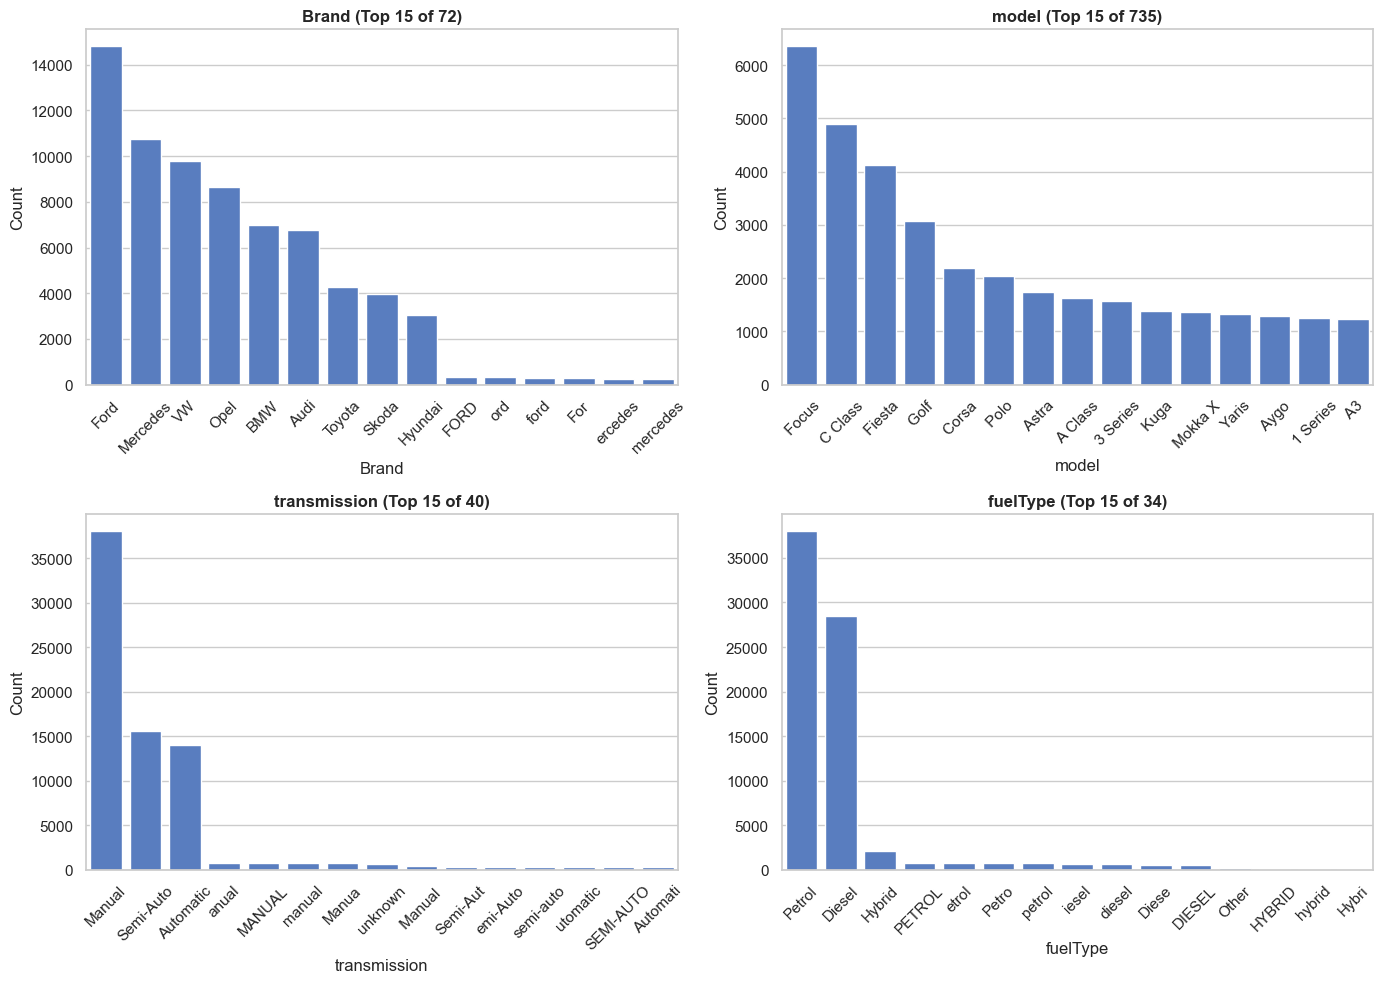

In [882]:
# Set style
sns.set(style="whitegrid", palette="muted")

n_cols = 2
n_rows = int(np.ceil(len(categorical_columns) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(categorical_columns):
    ax = axes[i]
    n_unique = train[col].nunique()
    
    # If few unique values: countplot 
    if n_unique <= 10:
        sns.countplot(data=train, x=col, order=train[col].value_counts().index, ax=ax)
        ax.set_title(f"{col} (n={n_unique})", fontsize=12, weight='bold')
        ax.set_xlabel('')
        ax.set_ylabel('Count')
        ax.tick_params(axis='x', rotation=45)
        
        total = len(train)
        for p in ax.patches:
            height = p.get_height()
            ax.text(p.get_x() + p.get_width() / 2, height,
                    f'{height/total:.1%}', ha='center', va='bottom', fontsize=9)

    # If medium number of categories (10–20): barplot (top 10)
    elif n_unique <= 20:
        counts = train[col].value_counts().head(15)
        sns.barplot(x=counts.index, y=counts.values, ax=ax)
        ax.set_title(f"{col} (Top 15 of {n_unique})", fontsize=12, weight='bold')
        ax.tick_params(axis='x', rotation=45)

    # If too many unique (model): plot only top 10
    else:
        top15 = train[col].value_counts().head(15)
        sns.barplot(x=top15.index, y=top15.values, ax=ax)
        ax.set_title(f"{col} (Top 15 of {n_unique})", fontsize=12, weight='bold')
        ax.tick_params(axis='x', rotation=45)
        ax.set_ylabel('Count')

# Remove empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


In [883]:
# ia fazer piecharts mas n faz sentido com tantas categorias, não se vê nada de jeito

#### 1.3.3. Interpretation

The categorical feature analysis reveals both dominant patterns and several data quality inconsistencies:

- <b>Brand</b>: The dataset is heavily skewed toward a few major manufacturers, with Ford, Mercedes, Volkswagen (VW), Opel, BMW and Audi representing a large share of all observations. However, duplicates such as "FORD" in uppercase indicate inconsistent capitalization. Additionally, there are clear truncation issues such as "ord", "For" and "ercedes", suggesting data-entry or parsing errors during dataset assembly. These anomalies will require targeted correction or mapping to their correct labels, which will be addressed later on.<br>

- <b>Model</b>: As expected, this variable displays very high cardinality; however, over 700 models seems too high - there are likely more capitalization / truncation errors in this column, they just don't appear in the top 15. The distribution is long-tailed, with only a few popular models (Focus, C Class, Fiesta, Golf) accounting for a significant portion of the data. Feature encoding will need to handle this imbalance carefully, so that our model doesn't start to predict only these models (generating a high accuracy but not being able to identify other types of cars).<br>

- <b>Transmission</b>: The data show strong dominance of Manual gearboxes (over half of all vehicles). Several near-duplicate entries ("manual", "MANUAL", "Manua", etc.) confirm the presence of text inconsistencies, that will later be standardized. We will also need to account for the ambiguous placeholders ("unknown").<br>

- <b>FuelType</b>: The dataset consists primarily of Petrol and Diesel vehicles, which together cover the vast majority of records. The appearance of variants such as "PETROL", "Petro", or "iesel" again suggests typographical noise that will need to be cleaned. Hybrid and Electric vehicles are underrepresented, which may affect model generalization for these classes.<br>

Overall, the categorical exploration highlights clear class imbalance and string normalization issues, both of which will be addressed in preprocessing to ensure consistency and reliable model performance.

### **1.4. Numerical Variables**
#### 1.4.1. Standard summary statistics


In this section, we will analyse, generally, the values and study to know what will be needed in processing and cleaning 

We have the following numerical features in the dataset:
year,
price,
mileage,
tax,
mpg,
engineSize,
paintQuality%,
previousOwners,
hasDamage (althoug representing a binary feature)

-> Year: In this sub-section, we can see the global statistical data of this feature, as well as the distribution by year and percentages

In [884]:
#year column analysis
print(train['year'].describe())
#year column analysis - value count in percentage
print(train['year'].value_counts(normalize=True, dropna=False) * 100)
print(train[train['year'] % 1 ==0]['year'].describe()) # statistics with only integer values

count    74482.000000
mean      2017.096611
std          2.208704
min       1970.000000
25%       2016.000000
50%       2017.000000
75%       2019.000000
max       2024.121759
Name: year, dtype: float64
year
2019.000000    26.681847
2017.000000    21.252287
2016.000000    15.139589
2018.000000    13.562713
2015.000000     7.546102
2020.000000     4.177800
2014.000000     3.856633
2013.000000     2.503521
NaN             1.962539
2012.000000     0.629171
2011.000000     0.418570
2010.000000     0.317218
2009.000000     0.300107
2008.000000     0.207969
2007.000000     0.161900
2010.676968     0.107933
2023.116964     0.101352
2005.000000     0.084240
2006.000000     0.081608
2010.746403     0.076343
2023.977311     0.072394
2023.389822     0.069762
2011.210853     0.065813
2010.565009     0.061864
2023.267989     0.056599
2023.605276     0.051334
2009.816757     0.048702
2010.371546     0.046069
2004.000000     0.046069
2024.121759     0.044753
2003.000000     0.038171
2023.367078     0

add graphic and distribution by 5 years 

hasDamage

In [885]:
# check if hasdamage is either 1 or 0
print(train['hasDamage'].value_counts(dropna=False))

hasDamage
0.0    74425
NaN     1548
Name: count, dtype: int64


Previous owners

In [886]:
#check if previous owners is an integer
print(train['previousOwners'].value_counts(dropna=False))
print(train['previousOwners'].describe()) #media de todos 
print(train[(train['previousOwners'] >= 0) & (train['previousOwners'] % 1 == 0)]['previousOwners'].describe()) #media de valores que sao inteiros e positivos


previousOwners
 0.000000    14879
 4.000000    14763
 1.000000    14754
 3.000000    14649
 2.000000    14644
 NaN          1550
-2.340306       84
 6.258231       78
 6.245835       64
-2.345650       58
-2.339360       58
 6.258371       50
 6.233082       46
-2.299439       43
 6.230180       37
-2.335123       37
-2.312260       34
 6.248251       32
-2.337445       25
 6.217724       21
 6.241779       20
-2.340102       17
 6.227898       15
-2.317331       15
Name: count, dtype: int64
count    74423.000000
mean         1.994580
std          1.472981
min         -2.345650
25%          1.000000
50%          2.000000
75%          3.000000
max          6.258371
Name: previousOwners, dtype: float64
count    73689.000000
mean         1.995427
std          1.417058
min          0.000000
25%          1.000000
50%          2.000000
75%          3.000000
max          4.000000
Name: previousOwners, dtype: float64


In [887]:
#analyse paintquality - percentage of values
print(train['paintQuality%'].value_counts(normalize=True, dropna=False) * 100)
# checking how many negative values are in the paintquality column
print(train[train['paintQuality%'] < 0]['paintQuality%'].count()) # --> result is 0
# how many values > 100 in paintquality
print(train[train['paintQuality%'] > 100]['paintQuality%'].count()) 
#descriptive statistics for paintquality 
print(train['paintQuality%'].describe())
#statistical general analysis of the "correct" (at least between the percentual appropriate range) 
print(train[(train['paintQuality%'] >= 0) & (train['paintQuality%'] <= 100)]['paintQuality%'].describe())

paintQuality%
NaN           2.005976
34.000000     1.509747
94.000000     1.484738
54.000000     1.466310
32.000000     1.457097
                ...   
125.453599    0.030274
2.725153      0.027641
1.638913      0.025009
125.188729    0.022376
3.254760      0.019744
Name: proportion, Length: 89, dtype: float64
0
367
count    74449.000000
mean        64.590667
std         21.021065
min          1.638913
25%         47.000000
50%         65.000000
75%         82.000000
max        125.594308
Name: paintQuality%, dtype: float64
count    74082.000000
mean        64.290118
std         20.633703
min          1.638913
25%         47.000000
50%         64.000000
75%         82.000000
max         99.000000
Name: paintQuality%, dtype: float64


In [888]:
print(train[train['paintQuality%'] < 0]['paintQuality%'].value_counts(normalize=True, dropna=False) * 100)


Series([], Name: proportion, dtype: float64)


In [889]:
# analyzing the engineSize column
print(train['engineSize'].value_counts(dropna=False))

engineSize
 2.000000    20105
 1.000000    13615
 1.500000     9156
 1.400000     7432
 1.600000     6381
 1.200000     4750
 3.000000     3806
 2.100000     3624
 NaN          1516
 1.800000     1192
 1.300000      920
 1.700000      618
 1.100000      385
 2.500000      312
 2.200000      295
 4.000000      295
 2.300000      181
 0.000000      180
 2.900000      116
-0.103493       84
 2.631200       80
 0.307074       65
 3.723712       63
 2.985793       52
 0.739534       52
 0.186425       52
 2.064119       51
 4.400000       46
 2.400000       43
 0.154529       39
 5.000000       38
 3.739235       38
 0.313407       35
 5.500000       31
 3.822758       27
 2.800000       26
 2.619641       25
 0.162866       24
 1.900000       23
 0.191462       21
 4.200000       20
 3.200000       19
 6.200000       19
 2.781776       19
 0.371127       18
 4.700000       18
 5.200000       17
 2.663113       17
 3.500000       12
 2.700000        7
 0.600000        4
 5.400000        2
 

In [890]:
# engine size descriptive statistics
print(train['engineSize'].describe())
print(train[train['engineSize'] > 0]['engineSize'].describe())



count    74457.000000
mean         1.660136
std          0.573462
min         -0.103493
25%          1.200000
50%          1.600000
75%          2.000000
max          6.600000
Name: engineSize, dtype: float64
count    74193.000000
mean         1.666161
std          0.565495
min          0.154529
25%          1.200000
50%          1.600000
75%          2.000000
max          6.600000
Name: engineSize, dtype: float64


In [891]:
#assessing the mileage column  
train['mileage'].value_counts(dropna=False)



mileage
NaN        1463
1000.0      577
10.0        560
5000.0      507
6000.0      340
           ... 
28088.0       1
7955.0        1
96040.0       1
2958.0        1
69072.0       1
Name: count, Length: 34809, dtype: int64

In [892]:
train['mileage'].describe()


count     74510.000000
mean      23004.184088
std       22129.788366
min      -58540.574478
25%        7423.250000
50%       17300.000000
75%       32427.500000
max      323000.000000
Name: mileage, dtype: float64

In [893]:
train[train['mileage']>0]['mileage'].describe()

count     74141.000000
mean      23352.797092
std       21620.630248
min           1.000000
25%        7556.000000
50%       17416.000000
75%       32510.000000
max      323000.000000
Name: mileage, dtype: float64

In [894]:
#tax collumn analysis
print(train['tax'].value_counts(dropna=False))
print(train['tax'].describe())
print(train[train['tax']>=0]['tax'].describe())


tax
145.0    32861
NaN       7904
150.0     7400
30.0      5781
20.0      5610
         ...  
130.0        1
520.0        1
295.0        1
245.0        1
535.0        1
Name: count, Length: 66, dtype: int64
count    68069.000000
mean       120.329078
std         65.521176
min        -91.121630
25%        125.000000
50%        145.000000
75%        145.000000
max        580.000000
Name: tax, dtype: float64
count    67691.000000
mean       121.259276
std         64.493191
min          0.000000
25%        125.000000
50%        145.000000
75%        145.000000
max        580.000000
Name: tax, dtype: float64


In [895]:
# mpg column analysis
train['mpg'].value_counts(dropna=False)



mpg
NaN     7926
60.1    4195
65.7    3188
54.3    2791
64.2    2459
        ... 
42.4       1
61.1       1
38.1       1
6.0        1
53.5       1
Name: count, Length: 218, dtype: int64

In [896]:
print(train['mpg'].describe())
print(train[train['mpg']>0]['mpg'].describe())

count    68047.000000
mean        55.152666
std         16.497837
min        -43.421768
25%         46.300000
50%         54.300000
75%         62.800000
max        470.800000
Name: mpg, dtype: float64
count    68011.000000
mean        55.204844
std         16.345534
min          1.100000
25%         46.300000
50%         54.300000
75%         62.800000
max        470.800000
Name: mpg, dtype: float64


In [897]:
#price analysis
print(train['price'].value_counts(dropna=False))
print(train['price'].describe())

price
9995     406
10995    360
8995     359
11000    334
12995    329
        ... 
21320      1
22416      1
39923      1
6301       1
25785      1
Name: count, Length: 11048, dtype: int64
count     75973.000000
mean      16881.889553
std        9736.926322
min         450.000000
25%       10200.000000
50%       14699.000000
75%       20950.000000
max      159999.000000
Name: price, dtype: float64


#### 1.4.2. Visualizations

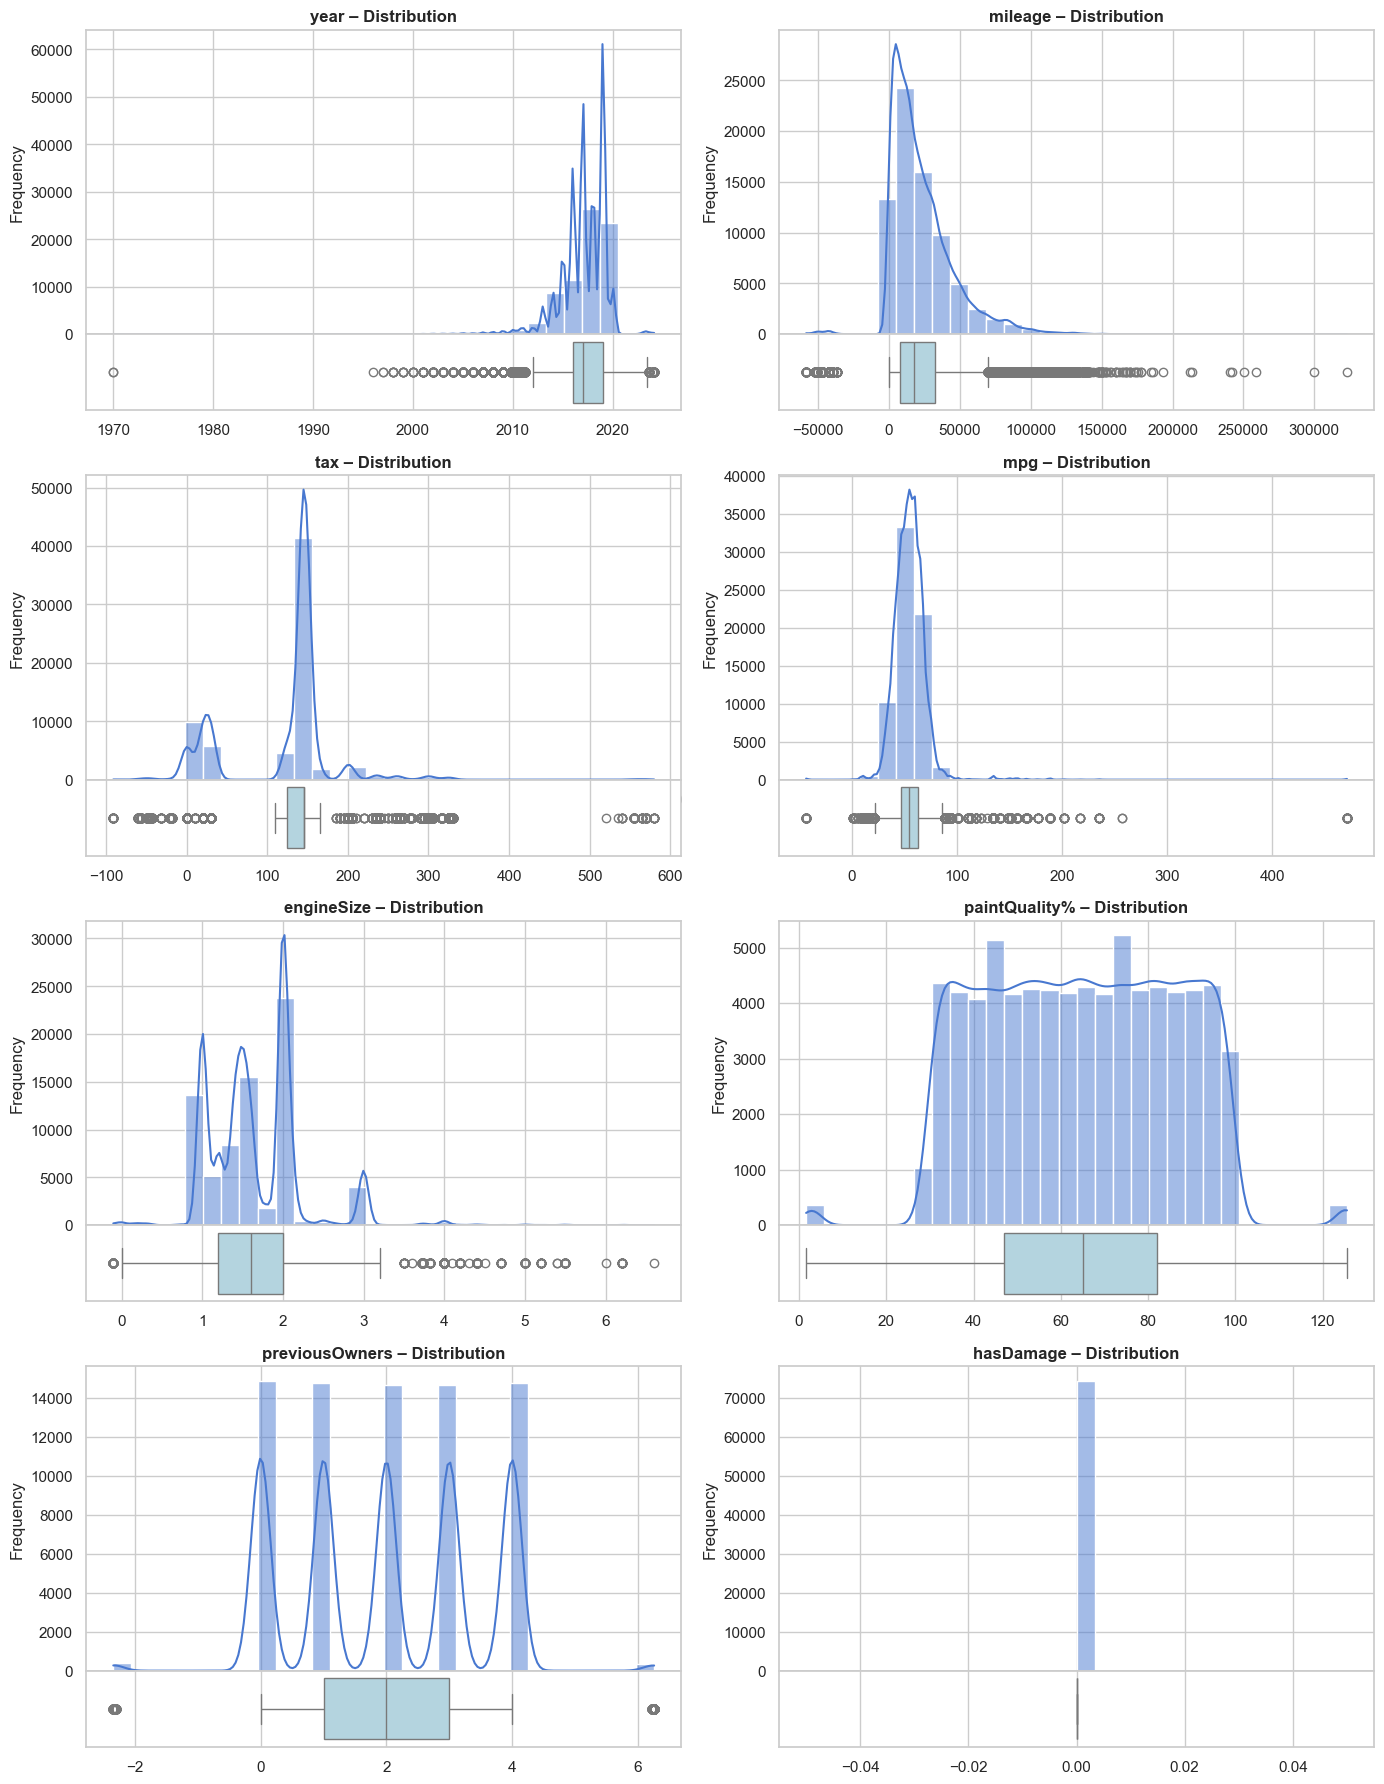

In [898]:
sns.set(style="whitegrid", palette="muted")

# Identify numerical columns 
numerical_columns = train.select_dtypes(include=['int64', 'float64']).columns
# Exclude target variable 'price' from the plots and carID(doesn't make sense to plot it)
numerical_columns = numerical_columns.drop(['price', 'carID'])

n_cols = 2
n_rows = int(np.ceil(len(numerical_columns) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4.5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(numerical_columns):
    ax = axes[i]

    # Plot histogram with KDE overlay
    sns.histplot(train[col], kde=True, bins=30, ax=ax)
    ax.set_title(f"{col} – Distribution", fontsize=12, weight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Frequency')

    # Boxplot below histogram 
    ax_box = ax.inset_axes([0, -0.25, 1, 0.25])
    sns.boxplot(x=train[col], ax=ax_box, color='lightblue')
    ax_box.set_xlabel('')
    ax_box.set_yticks([])
    ax_box.set_title('')

# Remove empty plots if any
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

#### 1.4.3. Interpretations

The numerical analysis highlights strong differences in distribution shapes, scales, and potential data quality issues across variables. Below is a feature-by-feature summary:

- <b>Year</b>: The distribution is highly concentrated between 2010 and 2020, reflecting a dataset composed mostly of recent vehicles. However, a few outliers from much earlier years (1970s–1990s) are visible, possibly representing incorrectly recorded registration dates or collectible cars. These entries may need to be reviewed during cleaning.<br>

- <b>Mileage</b>: This variable is heavily right-skewed, indicating that most vehicles have moderate mileage, with a small subset of very high-mileage cars (around 300 000 miles). Some negative or near-zero values appear, which are likely data entry or conversion errors and will be corrected or removed.<br>

- <b>Tax</b>: The distribution shows multiple peaks, reflecting standard tax brackets or policy tiers. A small number of extreme values above 400 are visible, suggesting big outliers. These could correspond to misclassifications or unique vehicle categories (such as high-emission models).<br>

- <b>mpg (Miles per Gallon)</b>: The variable is strongly centered around mid-range efficiency levels but shows a few implausible extreme values. The distribution's narrowness suggests that most vehicles share similar efficiency ratings, while outliers likely represent hybrid or performance cars.<br>

- <b>engineSize</b>: The distribution is multimodal, with peaks around 1.0L, 1.5L, and 2.0L (corresponding to typical engine configurations). Outliers above 5L likely correspond to high-performance or incorrectly entered values. Observations of 0 or below will be treated as errors.<br>

- <b>paintQuality%</b>: This feature is approximately uniform across its valid range, which is expected for a subjective or inspection-based score. However, a few values above 100% are clearly invalid and will need to be corrected.<br>

- <b>previousOwners</b>: The data show a discrete distribution with integer spikes at 0, 1, 2, 3, and 4 owners, which is typical for used-car markets. Outliers outside this logical range (negative or >5) indicate likely data-entry errors that should be handled before modeling. `previousOwners` = 0 likely represents cars that have not had a registered private owner (typically dealership demonstration or fleet vehicles) rather than brand-new cars; these cars often show lower mileage and higher prices relative to their age, though a small portion may also reflect missing or miscoded ownership data.<br>

- <b>hasDamage</b>: This variable behaves as a binary indicator (0 or 1), though its histogram appears compressed due to the overwhelming number of “0” (no damage) records (in fact, nearly all entries show 0 - and the ones that aren't 0, are missing values). This imbalance will need to be accounted for during feature encoding to avoid bias; or, more likely, it will be dropped.<br><br>


Overall, numerical variables exhibit non-normal distributions, significant right skewness, and some potentially invalid or extreme values. Before modeling, some preprocessing  will be necessary.

1.5. Cross analysis

## 2. 

In [899]:
#conseguimos perceber que há inconsistencias em todas as colunas categóricas
#começamos por passar todas as colunas categoricas para upper case e retirar os espaços em branco do inicio e fim da string
for column in categorical_columns:
    train[column] = train[column].str.upper().str.strip()  
    print(f"Unique values in column '{column}' after stripping and uppercasing: {train[column].unique()}") 


Unique values in column 'Brand' after stripping and uppercasing: ['VW' 'TOYOTA' 'AUDI' 'FORD' 'BMW' 'SKODA' 'OPEL' 'MERCEDES' 'FOR'
 'HYUNDAI' 'W' 'ORD' 'MW' nan 'YUNDAI' 'BM' 'TOYOT' 'UDI' 'OPE' 'V' 'PEL'
 'PE' 'MERCEDE' 'KODA' 'HYUNDA' 'AUD' 'ERCEDES' 'OYOTA' 'SKOD' 'KOD'
 'YUNDA' 'OR' 'ERCEDE' 'UD']
Unique values in column 'model' after stripping and uppercasing: ['GOLF' 'YARIS' 'Q2' 'FIESTA' '2 SERIES' '3 SERIES' 'A3' 'OCTAVIA'
 'PASSAT' 'FOCUS' 'INSIGNIA' 'A CLAS' 'Q3' 'FABIA' 'A CLASS' 'KA+'
 'GLC CLASS' 'I30' 'C CLASS' 'POLO' 'E CLASS' 'C CLAS' 'Q5' 'UP' 'C-HR'
 'MOKKA X' 'CORSA' 'ASTRA' 'TT' '5 SERIES' 'AYGO' '4 SERIES' 'SLK' 'VIVA'
 'T-ROC' 'ECOSPORT' 'TUCSON' 'ECOSPOR' nan 'X-CLASS' 'CL CLASS' 'IX20'
 'I20' 'RAPID' 'A1' 'AURIS' 'SHARAN' 'ADAM' 'X3' 'A8' 'GLS CLASS' 'B-MAX'
 'A4' 'KONA' 'I10' 'MOKKA' 'S-MAX' 'X2' 'CROSSLAND X' 'TIGUAN' 'A5'
 'GLE CLASS' 'ZAFIRA' 'IONIQ' 'A6' 'MONDEO' 'YETI OUTDOOR' 'X1' 'SCALA'
 'S CLASS' '1 SERIES' 'KAMIQ' 'KUGA' 'TOURNEO CONNECT' 'Q7' 'GLA C

/var/folders/bd/t15rp69d53n0dgbv492qs36h0000gn/T/ipykernel_51068/996597199.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/var/folders/bd/t15rp69d53n0dgbv492qs36h0000gn/T/ipykernel_51068/996597199.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/var/folders/bd/t15rp69d53n0dgbv492qs36h0000gn/T/ipykernel_51068/996597199.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/var/folders/bd/t15rp69d53n0dgbv492qs36h0000gn/T/ipykernel_51068/996597199.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and w

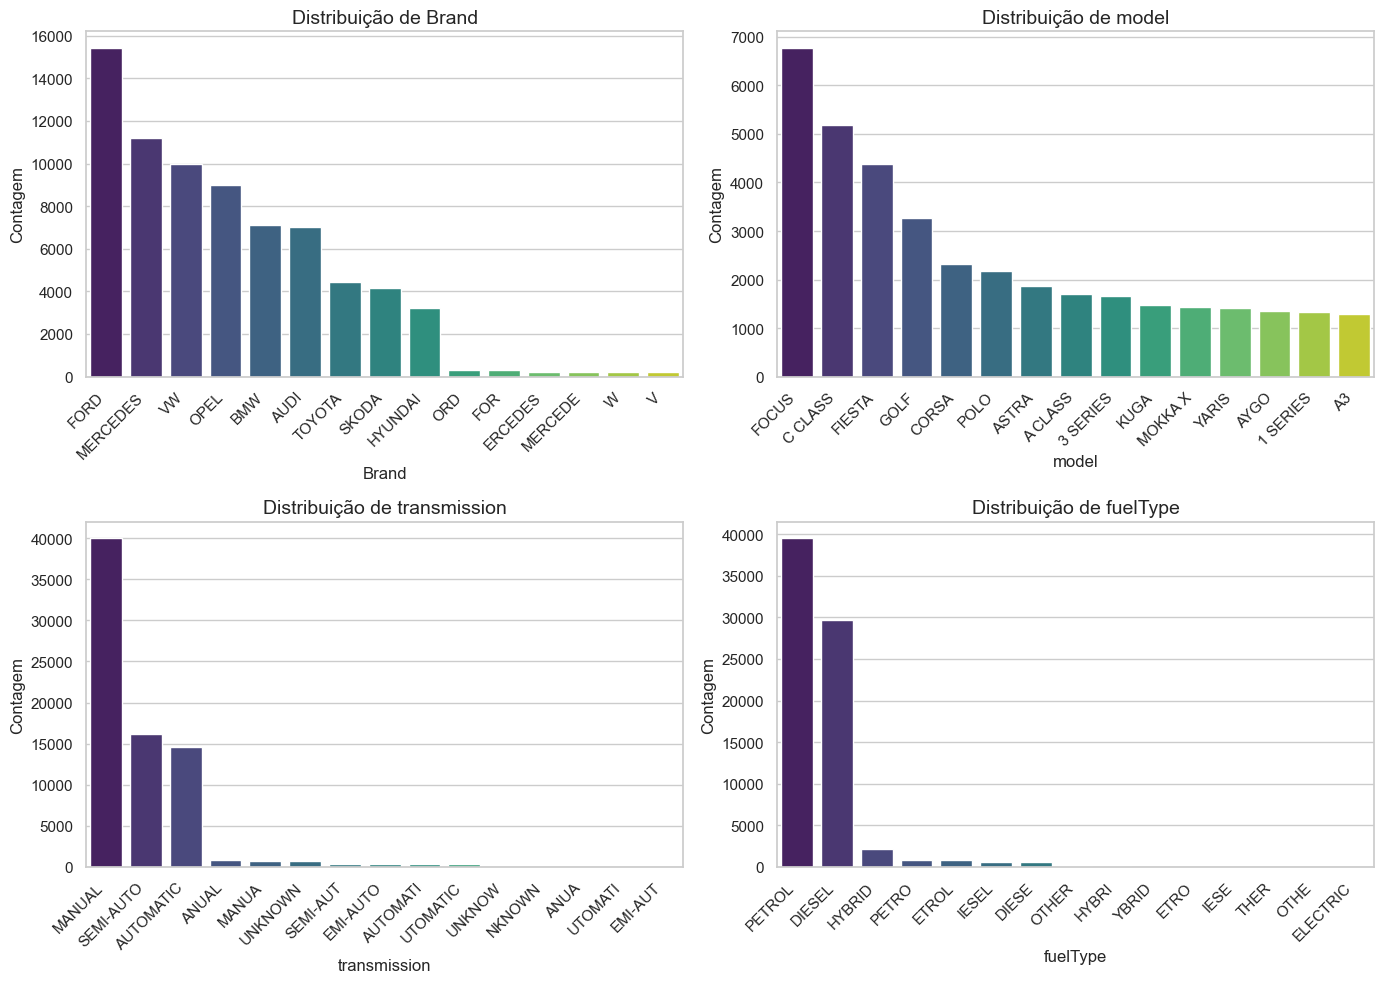

In [900]:
sns.set(style="whitegrid")

# Cria um subplot por variável
n_cols = 2
n_rows = (len(categorical_columns) + 1) // n_cols

plt.figure(figsize=(14, 5 * n_rows))

for i, col in enumerate(categorical_columns, 1):
    plt.subplot(n_rows, n_cols, i)
    
    # Mostra as 15 categorias mais comuns
    top_values = train[col].value_counts().head(15)
    
    sns.barplot(
        x=top_values.index,
        y=top_values.values,
        palette="viridis"
    )
    
    plt.title(f"Distribuição de {col}", fontsize=14)
    plt.ylabel("Contagem")
    plt.xlabel(col)
    plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

In [901]:
# o meu objetivo com estes graficos era perceber se existia a possibilidade de definir um threshold de frequencia para distinguir valores validos de invalidos
# so que nao funciona para os modelos claramente
# no entanto para as outras var alem do model acho que pode funcionar, so que por exemplo em fueltype tens o eletric que é valido so que como só tem uma amostra vai acabar por nao estar na lista dos validos, mas dá para resolver acho eu

In [902]:
train['model'].value_counts()

model
FOCUS             6775
C CLASS           5194
FIESTA            4384
GOLF              3261
CORSA             2319
                  ... 
TIGUAN ALLSPAC       1
8 SERIE              1
230                  1
FOX                  1
TERRACAN             1
Name: count, Length: 296, dtype: int64

In [903]:
#esta função eu acabei por perceber que não funciona porque por exemplo para o caso de UD que pode ser tanto audi como hyundai, e se eu substituir logo por audi ou hyundai (dependendo do que vai aparecer primeiro), depois quando chegar a hyundai ou audi ja nao vou conseguir perceber que é ambiguo

def normalize_by_containment(values):
    valores_unicos = [v for v in pd.Series(values).dropna().unique() if isinstance(v, str)]
    lista_limpa = []
    mapping = {}
    ambiguos = set()

    for v in valores_unicos:
        # procura valores já na lista que contenham ou sejam contidos por v
        candidatos = [x for x in lista_limpa if v in x or x in v]

        # se não há candidatos, adiciona
        if not candidatos:
            lista_limpa.append(v)
            mapping[v] = v
            continue

        # se há mais de um candidato, é ambíguo — não muda, mas regista
        if len(candidatos) > 1:
            mapping[v] = v
            ambiguos.add(v)
            continue

        # se há só um candidato
        c = candidatos[0]
        if v in c:
            # valor é substring do existente
            mapping[v] = c
        elif c in v:
            # valor é superstring — substitui o existente
            lista_limpa.remove(c)
            lista_limpa.append(v)
            # atualiza todos que apontavam para c
            for k in list(mapping.keys()):
                if mapping[k] == c:
                    mapping[k] = v
            mapping[v] = v
        else:
            mapping[v] = v  # fallback (não devia acontecer)

    valores_normalizados = [mapping.get(v, v) for v in values]
    return valores_normalizados, sorted(list(ambiguos))


ambiguous_summary = {}

for col in categorical_columns:
    print(f"\nNormalizando coluna: {col}")

    # aplica a função
    train[col], ambiguos = normalize_by_containment(train[col])

    # guarda os ambíguos encontrados (se houver)
    if ambiguos:
        ambiguous_summary[col] = ambiguos
        print(f" Valores ambíguos encontrados ({len(ambiguos)}): {ambiguos}")
    else:
        print(" Nenhum valor ambíguo encontrado.")




Normalizando coluna: Brand
 Valores ambíguos encontrados (1): ['W']

Normalizando coluna: model
 Valores ambíguos encontrados (18): ['A', 'ADA', 'CADDY', 'I', 'IQ', 'K', 'KA', 'M', 'Q', 'RAV', 'RS', 'S CLAS', 'SL', 'T', 'U', 'VERS', 'X', 'Z']

Normalizando coluna: transmission
 Nenhum valor ambíguo encontrado.

Normalizando coluna: fuelType
 Nenhum valor ambíguo encontrado.


In [904]:
#ignorem esta função sou eu a pensar, mas aqui esta vai ser a função que vou usar para normalizar os valores depois de ter a lista dos valores válidos 


# aqui vou ter de criar uma lista so com velores que nao tem interseção e a partir daí começo a fazer as comparações
# ha aqui tambem um problema que é "etro" tambem esta em petrol e other com a função do contain... 
# é preciso mudar isto de modo a que, quando estamos a analisar um valor tambem sejam tidos em conta os valores que vêm a seguir para analise, porque por exemplo, UD pode estar para representar AUDI mas tambem Hyundai, nao sabemos de que forma os dados foram alterador, e para estar a prova de bala, preciso que nao se susbtituam logo valores sabendo que pode vir um nome a seguir que o torne ambiguo, faz sentido?


#o que quero fazer é, criar ua lista de todas os valores unicos que nao estao contidos uns nos outros
# a partir daí, das palavras que sobraraam ver as que estão contidas em apenas 1 palavra da lista inicial 
# se estiverem contidas em mais do que uma palavra, são ambiguas e não se alteram
#se estiveram contidas numa so palavra entao passam a ser a palavra em que estao contidas
#depois para as palavras que deram ambiguas, vou criar uma função que recebe a lista de ambiguos e uma coluna de suporte, isto é, para cada valor ambiguo, vamos verificar na coluna de suporte se ha mais iguais por exemplo; temos uma marca ambigua, vamos ver se na coluna model ha mais models iguais, se houver, então alteramos a marca para a marca que está na coluna model
# os que nao nao houver outro model assim, 


def normalize_by_containment(values):
    valores_unicos = [v for v in pd.Series(values).dropna().unique() if isinstance(v, str)]
    lista_limpa = []
    mapping = {}
    ambiguos = set()

    for v in valores_unicos:
        # procura valores já na lista que contenham ou sejam contidos por v
        candidatos = [x for x in lista_limpa if v in x or x in v]

        # se não há candidatos, adiciona
        if not candidatos:
            lista_limpa.append(v)
            mapping[v] = v
            continue

        # se há mais de um candidato, é ambíguo — não muda, mas regista
        if len(candidatos) > 1:
            mapping[v] = v
            ambiguos.add(v)
            continue

        # se há só um candidato
        c = candidatos[0]
        if v in c:
            # valor é substring do existente
            mapping[v] = c
        elif c in v:
            # valor é superstring — substitui o existente
            lista_limpa.remove(c)
            lista_limpa.append(v)
            # atualiza todos que apontavam para c
            for k in list(mapping.keys()):
                if mapping[k] == c:
                    mapping[k] = v
            mapping[v] = v
        else:
            mapping[v] = v  # fallback (não devia acontecer)

    valores_normalizados = [mapping.get(v, v) for v in values]
    return valores_normalizados, sorted(list(ambiguos))


In [905]:
#normalizar os valores de cada coluna categórica
ambiguous_summary = {}

for col in categorical_columns:
    print(f"\n Coluna normalizada: {col}")

    train[col], ambiguos = normalize_by_containment(train[col])

    if ambiguos:
        ambiguous_summary[col] = ambiguos
        print(f" Valores ambíguos encontrados ({len(ambiguos)}): {ambiguos}")
    else:
        print(" Nenhum valor ambíguo encontrado.")
  


 Coluna normalizada: Brand
 Valores ambíguos encontrados (1): ['W']

 Coluna normalizada: model
 Valores ambíguos encontrados (18): ['A', 'ADA', 'CADDY', 'I', 'IQ', 'K', 'KA', 'M', 'Q', 'RAV', 'RS', 'S CLAS', 'SL', 'T', 'U', 'VERS', 'X', 'Z']

 Coluna normalizada: transmission
 Nenhum valor ambíguo encontrado.

 Coluna normalizada: fuelType
 Nenhum valor ambíguo encontrado.


#### **Missing Values**

In [906]:
#counting the number of duplicated rows
print(train.duplicated().sum()) #0 duplicated rows
#porque seria importante?

0


In [907]:
#contagem de missing values por coluna e qual a percentagem 
missing_values = train.isnull().sum()
missing_percentage = (train.isnull().sum() / len(train)) * 100
missing_data = pd.DataFrame({'Missing Values': missing_values, 'Percentage': missing_percentage})
print(missing_data)
#lots of missing values in all the colums except the carID and price

                Missing Values  Percentage
carID                        0    0.000000
Brand                     1521    2.002027
model                     1517    1.996762
year                      1491    1.962539
price                        0    0.000000
transmission              1522    2.003343
mileage                   1463    1.925684
fuelType                  1511    1.988864
tax                       7904   10.403696
mpg                       7926   10.432654
engineSize                1516    1.995446
paintQuality%             1524    2.005976
previousOwners            1550    2.040198
hasDamage                 1548    2.037566


In [908]:
# temos duas categorias principais de missing values, de 2% e de 10% de missing values 
# as com percentagem de missing values de 2% penso que nao consistem numa percentagem de missing values significativa 
# vamos analisar a distribuicao dos dados para perceber que abordagem faz mais sentido
# analisar garficos para perceber o que fazer com os missing values 


<Axes: >

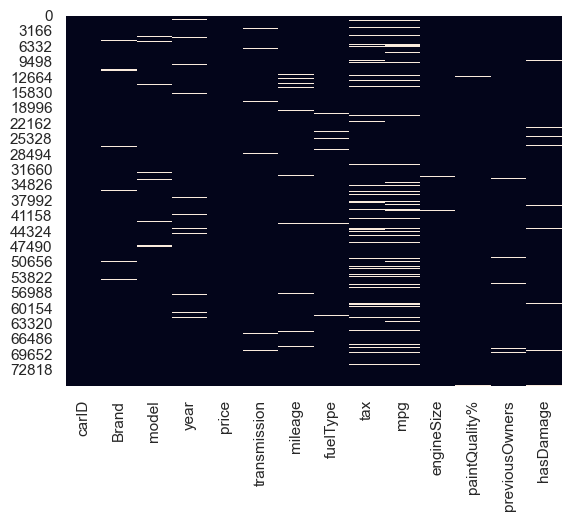

In [909]:
sns.heatmap(train.isna(), cbar=False)

In [910]:
# Com este gráfico podemos reparar que quase todos os missing values de tax e mpg que são as variaveis que têm % de missing values mais significativa, estão juntos, isto faz sentido uma vez que carros eletricos ou hibridos(aqui nao sei se se aplica), nao têm mpg e estao muitas vezes isentos de taxas

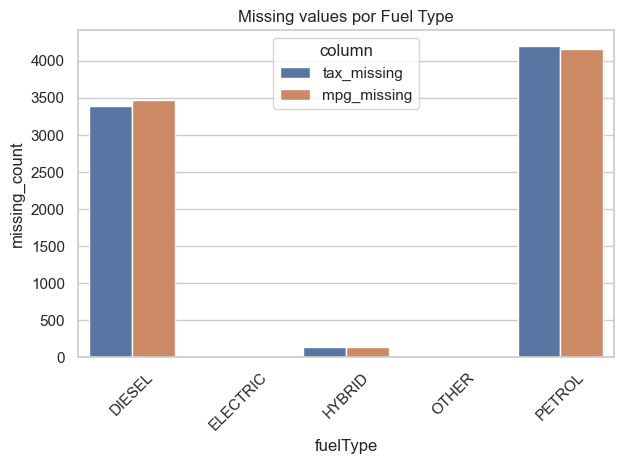

In [911]:
train['tax_missing'] = train['tax'].isna()
train['mpg_missing'] = train['mpg'].isna()

missing_counts = train.groupby('fuelType')[['tax_missing', 'mpg_missing']].sum().reset_index()
missing_melted = missing_counts.melt(id_vars='fuelType', var_name='column', value_name='missing_count')


sns.barplot(data=missing_melted, x='fuelType', y='missing_count', hue='column')
plt.title('Missing values por Fuel Type')
plt.xticks(rotation=45)  
plt.tight_layout()
plt.show()



In [912]:
# fiz este grafico para tentar provar o meu ponto anterior e o grafico provou me exatamente o contrario, giro

## Alguns graficos e estatisticas que podem fazer sentido (não acabei)

In [913]:
#calculate some basic statistics for numerical columns
display(train.describe())

,carID,year,price,mileage,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
count,75973.000000,74482.000000,75973.000000,74510.000000,68069.000000,68047.000000,74457.000000,74449.000000,74423.000000,74425.0
mean,37986.000000,2017.096611,16881.889553,23004.184088,120.329078,55.152666,1.660136,64.590667,1.994580,0.0
std,21931.660338,2.208704,9736.926322,22129.788366,65.521176,16.497837,0.573462,21.021065,1.472981,0.0
min,0.000000,1970.000000,450.000000,-58540.574478,-91.121630,-43.421768,-0.103493,1.638913,-2.345650,0.0
25%,18993.000000,2016.000000,10200.000000,7423.250000,125.000000,46.300000,1.200000,47.000000,1.000000,0.0
50%,37986.000000,2017.000000,14699.000000,17300.000000,145.000000,54.300000,1.600000,65.000000,2.000000,0.0
75%,56979.000000,2019.000000,20950.000000,32427.500000,145.000000,62.800000,2.000000,82.000000,3.000000,0.0
max,75972.000000,2024.121759,159999.000000,323000.000000,580.000000,470.800000,6.600000,125.594308,6.258371,0.0


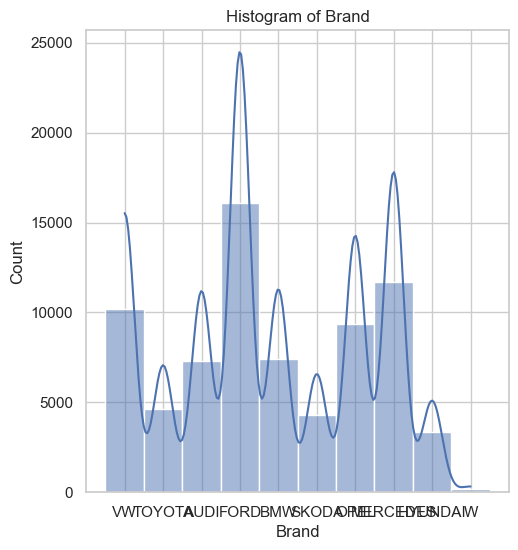

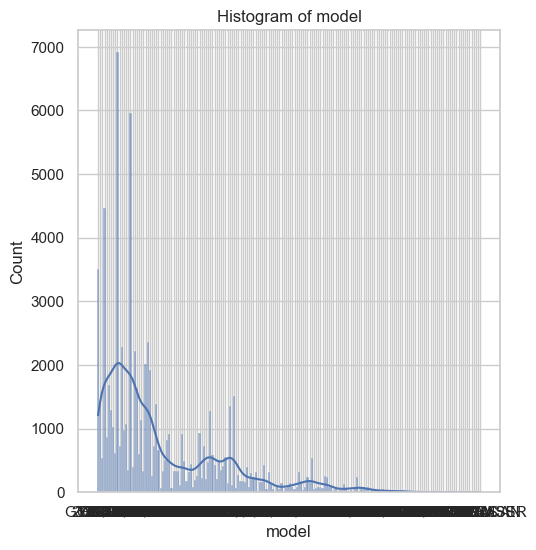

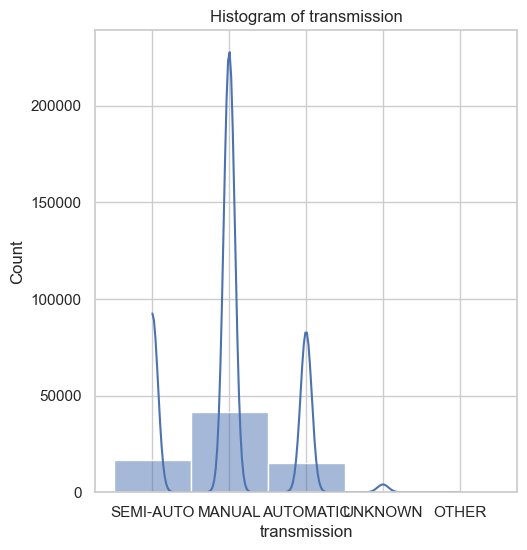

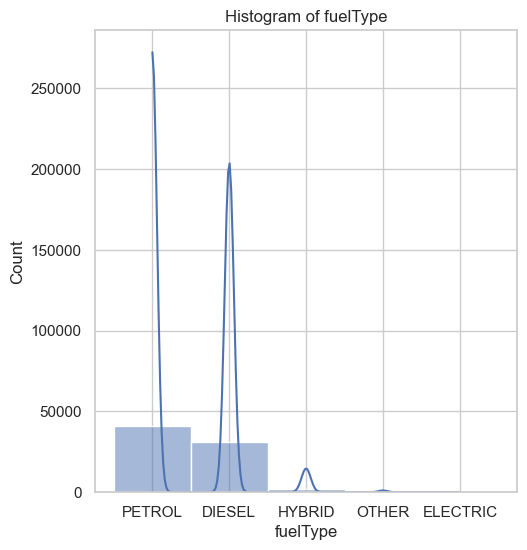

In [914]:
#Create graphics for numerical columns(histograms, boxplots, scatter plots)
numerical_columns = train.select_dtypes(include=[np.number]).columns.tolist()
for column in categorical_columns:
    plt.figure(figsize=(12, 6))
    
    plt.subplot(1, 2, 1)
    sns.histplot(train[column].dropna(), kde=True)
    plt.title(f'Histogram of {column}')
    
    plt.show()

#fazer mais graficos e tirar boas conclusoes dos gráficos 


## Analyzing the numerical data 

The dataset contains the following **numerical features**:
- `year`
- `price`
- `mileage`
- `tax`
- `mpg`
- `engineSize`
- `paintQuality%`
- `previousOwners`,
- `hasDamage` (althoug representing a binary feature)

In this sub-section, we will further investigate some of the aspects previously identified, as well as explore the data throughout and after the transformations. These transformations include dealing with missing values, checking and correcting, when apllicable, outliers and general anomalies, with the goal of obtaining a more consistent dataset - not only from a computational and mathematical point of view, but also within the business context of car sales. 

## 2.2.1. Year column

The "year" column contains values between 1970 and approximately 2024. The presence of decimal values may result from typos or from calculating the fractional number of years (i.e. including the number of months). However, the exact number of months a car has is typically not very relevant for price estimation - the car's age in full years matters most. Additionally, users will probably not calculate (or at least not correctly) the exact fractional age of the car. 

-> Therefore, we round all "year" values down to the floor integer. 

Moreover, the entries that didn't contain a "year" value were removed from the dataset. This decision is based on the fact that a car's year is one of the most relevant factors in determining its price. Replacing these missing values with a constant or with a statistical estimate (such as the mean or median) could lead to unreliable results. Since they represent only about 2% of the dataset, removing them was considered the safest option to ensure reliable outcomes. 

In [915]:
train = train.dropna(subset=['year'])  #removing rows with missing year values
train['year'] = np.floor(train['year']) #rounding down to the nearest integer
test['year'] = np.floor(test['year']) 


In [916]:
train['year'].describe()

count    74482.000000
mean      2017.091821
std          2.211113
min       1970.000000
25%       2016.000000
50%       2017.000000
75%       2019.000000
max       2024.000000
Name: year, dtype: float64

Although the `year` column seems to be mathematically correct, it does not comply with what is stated in the handout - "car database from 2020". Therefore, in our understanding, this is an anomaly and we will round all values above 2020 to that year.  

In [917]:
train.loc[train['year'] > 2020, 'year'] = 2020

In [918]:
(train['year'].value_counts(normalize=True, dropna=False) * 100).round(2).sort_values

<bound method Series.sort_values of year
2019.0    27.22
2017.0    21.68
2016.0    15.44
2018.0    13.83
2015.0     7.70
2020.0     4.74
2014.0     3.93
2013.0     2.55
2012.0     0.67
2010.0     0.65
2011.0     0.51
2009.0     0.36
2008.0     0.21
2007.0     0.17
2005.0     0.09
2006.0     0.08
2004.0     0.05
2003.0     0.04
2002.0     0.03
2001.0     0.02
2000.0     0.01
1998.0     0.01
1999.0     0.01
1970.0     0.00
1997.0     0.00
1996.0     0.00
Name: proportion, dtype: float64>

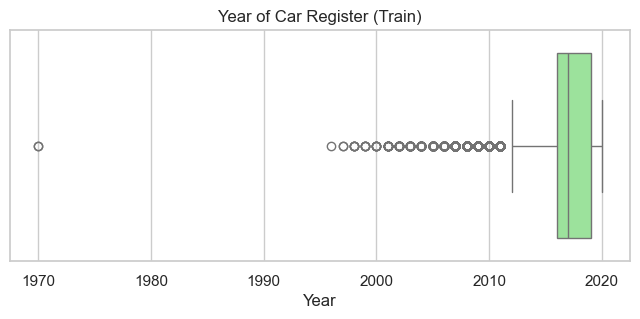

In [919]:
plt.figure(figsize=(8,3))
sns.boxplot(x=train['year'], color='lightgreen')
plt.title('Year of Car Register (Train)')
plt.xlabel('Year')
plt.show()


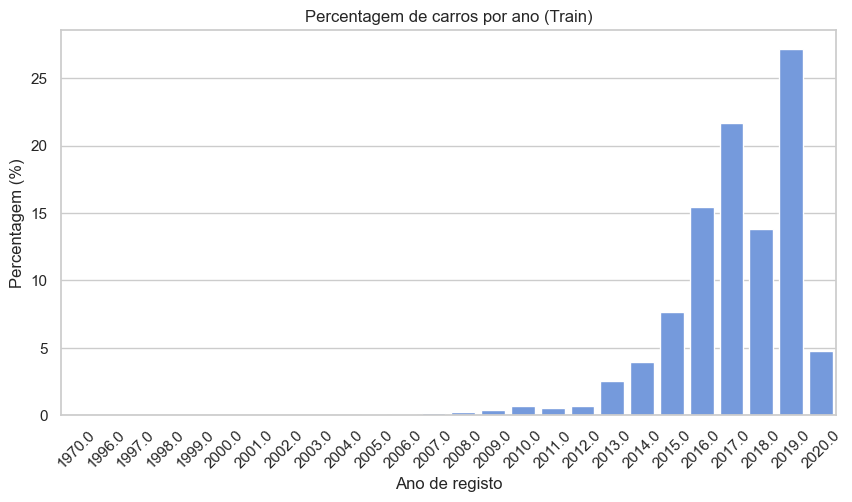

In [920]:
year_counts = train['year'].value_counts(normalize=True).sort_index() * 100

plt.figure(figsize=(10,5))
sns.barplot(x=year_counts.index, y=year_counts.values, color='cornflowerblue')
plt.title('Percentagem de carros por ano (Train)')
plt.xlabel('Ano de registo')
plt.ylabel('Percentagem (%)')
plt.xticks(rotation=45)
plt.show()


## 2.2.2. `hasDamage` column

As we previously observed, the dataset only includes cars without signs of damage or a missing evaluations. One possible reason could be that the resale company only accepts cars in good condition, however this is just a supposition. 
In conclusion, we decided to drop this column, because it did not appear to be relevant for our analysis.

In [921]:
train.drop("hasDamage", axis=1) 

,carID,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,tax_missing,mpg_missing
0,69512,VW,GOLF SV,2016.0,22290,SEMI-AUTO,28421.0,PETROL,NaN,11.417268,2.0,63.0,4.000000,True,False
1,53000,TOYOTA,YARIS,2019.0,13790,MANUAL,4589.0,PETROL,145.0,47.900000,1.5,50.0,1.000000,False,False
2,6366,AUDI,Q2,2019.0,24990,SEMI-AUTO,3624.0,PETROL,145.0,40.900000,1.5,56.0,4.000000,False,False
3,29021,FORD,FIESTA,2018.0,12500,MANUAL,9102.0,PETROL,145.0,65.700000,1.0,50.0,-2.340306,False,False
4,10062,BMW,2 SERIES,2019.0,22995,MANUAL,1000.0,PETROL,145.0,42.800000,1.5,97.0,3.000000,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75968,37194,MERCEDES,GLC CLASS,2015.0,13498,MANUAL,14480.0,PETROL,125.0,53.300000,2.0,78.0,0.000000,False,False
75969,6265,AUDI,Q3,2013.0,12495,SEMI-AUTO,52134.0,DIESEL,200.0,47.900000,2.0,38.0,2.000000,False,False
75970,54886,TOYOTA,AYGO,2017.0,8399,AUTOMATIC,11304.0,PETROL,145.0,67.000000,1.0,57.0,3.000000,False,False
75971,860,AUDI,Q3,2015.0,12990,MANUAL,69072.0,DIESEL,125.0,60.100000,2.0,74.0,2.000000,False,False


## 2.2.3. `Previous owners` column

We observed that the main issues with this column were the presence of negative, null, and missing values, as well as values with decimal places.
We decided to convert negative values to their absolute values and round them to the nearest integer. For missing values, since the range of values is small and there are no outliers, they were replaced with the mean.

In [922]:
# valores negativos passam a absolutos 
train['previousOwners'] = train['previousOwners'].abs()

# valores inteiros passam a arrendados 
train['previousOwners'] = train['previousOwners'].round()

# calcular media nova 
# ver se mean ou median ou mode 
train['previousOwners'] = train['previousOwners'].fillna(train['previousOwners'].mean())

# substituir nans por isso 
train['previousOwners'].describe()

count    74482.000000
mean         2.015050
std          1.422683
min          0.000000
25%          1.000000
50%          2.000000
75%          3.000000
max          6.000000
Name: previousOwners, dtype: float64

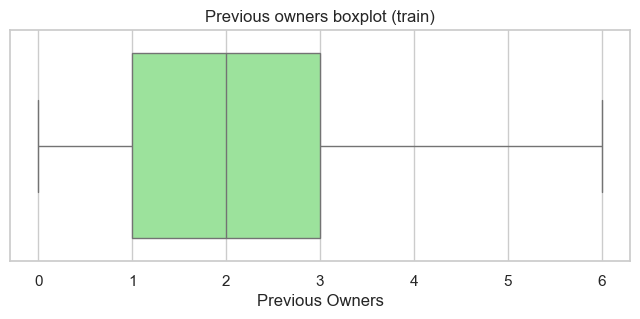

In [923]:
plt.figure(figsize=(8,3))
sns.boxplot(x=train['previousOwners'], color='lightgreen')
plt.title('Previous owners boxplot (train)')
plt.xlabel('Previous Owners')
plt.show()


- We also found entries of cars with 0 previous owners, which, at first, did not seem reasonable. However, upon further thinking, the value 0 could indicate that the car was used in dealerships for test drives, which are usually not marketed as used cars (in the conventional way).
- Since these company cars are essentially new, they should not be older than 2 years or have over 15 000 miles (these ceiling values were defined after group discussion and broad search, rather than based on a concrete source).
- If the cars do not comply with these conditions, it's likely a typo or a user registering their car as having 0 owners before themselves, for instance. Therefore, those values were replaced with 1.

In [924]:
print(train[train['previousOwners'] == 0]['mileage'].sort_values())
# inaccurate 0 owners
max_year = train['year'].max() # after our changes it will be 2020
inac_own_condition = (
    ((max_year - train['year']) > 2) |
    (train['mileage'] > 15000)
) & (train['previousOwners'] == 0)
# print(inac_own_condition.sum()) #14555
train.loc[inac_own_condition, 'previousOwners'] = 1


56700   -58540.574478
29826   -58540.574478
20403   -58540.574478
50477   -58540.574478
36310   -58540.574478
             ...     
75176             NaN
75217             NaN
75344             NaN
75585             NaN
75809             NaN
Name: mileage, Length: 14588, dtype: float64


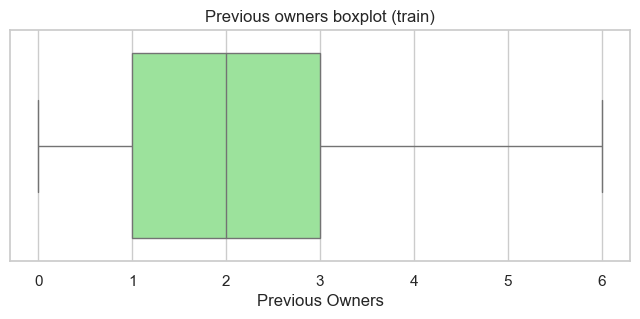

In [925]:
plt.figure(figsize=(8,3))
sns.boxplot(x=train['previousOwners'], color='lightgreen')
plt.title('Previous owners boxplot (train)')
plt.xlabel('Previous Owners')
plt.show()


## 2.2.4. `paintQuality%` column

- We did not find negative values, however we found percentages over 100. We decided to truncate values exceeding 100% to 100%. We chose to keep values with decimal places.
- Missing values where replaced with the mean value, because the dataset did not contain outliers. 

In [926]:
# set max to 100 
train['paintQuality%'] = train['paintQuality%'].clip(upper=100)

In [927]:
train['paintQuality%'].describe()

count    72989.000000
mean        64.469578
std         20.736090
min          1.638913
25%         47.000000
50%         65.000000
75%         82.000000
max        100.000000
Name: paintQuality%, dtype: float64

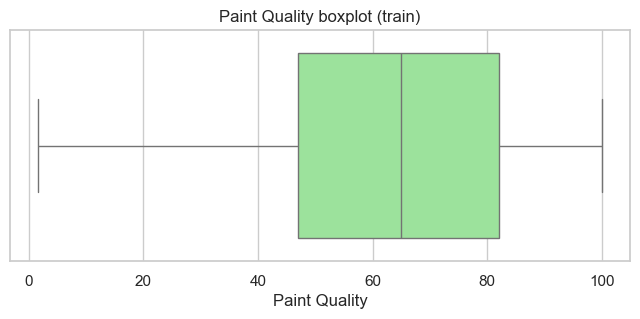

In [928]:
plt.figure(figsize=(8,3))
sns.boxplot(x=train['paintQuality%'], color='lightgreen')
plt.title('Paint Quality boxplot (train)')
plt.xlabel('Paint Quality')
plt.show()

In [929]:
train['paintQuality%'] = train['paintQuality%'].fillna(train['paintQuality%'].mean())

In [930]:
train['paintQuality%'].describe()

count    74482.000000
mean        64.469578
std         20.527206
min          1.638913
25%         47.000000
50%         64.469578
75%         82.000000
max        100.000000
Name: paintQuality%, dtype: float64

## 2.2.5. `mileage%` column

- We identified missing and negative values that were replaced, respectively, with the median value (because we identified multiple outliers as seen in the end of this section) and their absolute value (we atributed the negative values to typos). 

In [931]:
train['mileage'] = pd.to_numeric(train['mileage'], errors='coerce')

In [932]:
train['mileage'].value_counts(dropna=False)


mileage
NaN         1441
1000.0       568
10.0         545
5000.0       501
6000.0       332
            ... 
11495.0        1
6098.0         1
106654.0       1
33466.0        1
69072.0        1
Name: count, Length: 34383, dtype: int64

In [933]:
train['mileage'].describe()


count     73041.000000
mean      23001.827587
std       22110.730174
min      -58540.574478
25%        7427.000000
50%       17307.000000
75%       32423.000000
max      323000.000000
Name: mileage, dtype: float64

In [934]:
train[train['mileage']>0]['mileage'].describe()

count     72680.000000
mean      23349.750729
std       21602.004864
min           1.000000
25%        7562.000000
50%       17429.000000
75%       32502.000000
max      323000.000000
Name: mileage, dtype: float64

In [935]:
train['mileage'] = train['mileage'].abs()

In [936]:
train['mileage'].describe()


count     73041.000000
mean      23466.864874
std       21616.531134
min           1.000000
25%        7617.000000
50%       17540.000000
75%       32810.000000
max      323000.000000
Name: mileage, dtype: float64

In [937]:
medianval = train['mileage'].median()
print(medianval)
train['mileage'] = train['mileage'].fillna(medianval)

17540.0


In [938]:
train['mileage'].describe()


count     74482.000000
mean      23352.198078
std       21421.961493
min           1.000000
25%        7821.250000
50%       17540.000000
75%       32423.000000
max      323000.000000
Name: mileage, dtype: float64

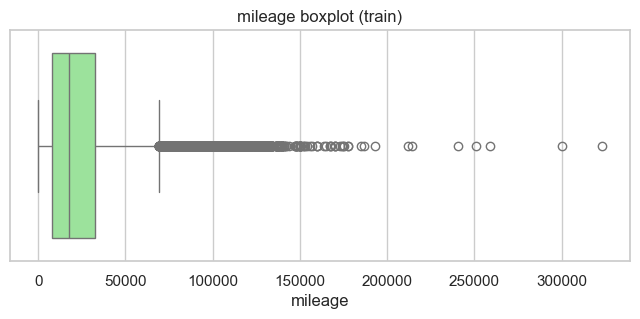

In [939]:
plt.figure(figsize=(8,3))
sns.boxplot(x=train['mileage'], color='lightgreen')
plt.title('mileage boxplot (train)')
plt.xlabel('mileage')
plt.show()


In [940]:
Q1 = train['mileage'].quantile(0.25)
Q3 = train['mileage'].quantile(0.75)
IQR = Q3 - Q1

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
lower_bound = Q1 - 1.5 * IQR   # values below this are outliers
upper_bound = Q3 + 1.5 * IQR   # values above this are outliers

print("Outliers start below:", lower_bound)
print("Outliers start above:", upper_bound)
outliers = train[(train['mileage'] > upper_bound)]
print("Number of outliers:", len(outliers))


Q1: 7821.25
Q3: 32423.0
IQR: 24601.75
Outliers start below: -29081.375
Outliers start above: 69325.625
Number of outliers: 3265


- **Outliers**: We identified several outliers; however, when considering the real-world context of used cars, these values may vary a lot between vehicles. Even a more recent car can have higher mileage and there isn't any definitive way to determine whether such values are errors or valid, as they can still make sense in a real-world scenario.

## 2.2.6. `tax` column

In the tax column we identified negative values that were replaced with their absolute value. We also found missing values that were replaced with the median, because of the heavy presence of outliers.

In [941]:
train['tax'] = train['tax'].abs()

In [942]:
print(train['tax'].describe())


count    66742.000000
mean       120.836059
std         64.575336
min          0.000000
25%        125.000000
50%        145.000000
75%        145.000000
max        580.000000
Name: tax, dtype: float64


In [943]:
train['tax'] = train['tax'].fillna(train['tax'].median())


In [944]:
train['tax'].describe()

count    74482.000000
mean       123.347121
std         61.571149
min          0.000000
25%        125.000000
50%        145.000000
75%        145.000000
max        580.000000
Name: tax, dtype: float64

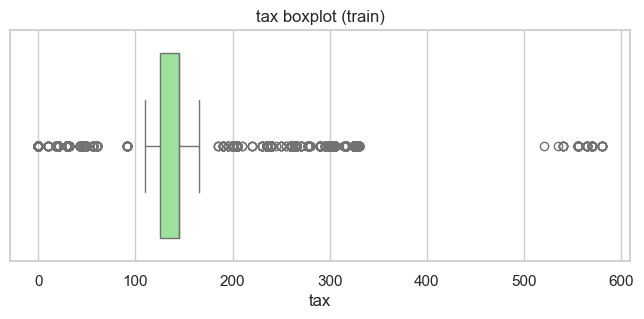

In [945]:
plt.figure(figsize=(8,3))
sns.boxplot(x=train['tax'], color='lightgreen')
plt.title('tax boxplot (train)')
plt.xlabel('tax')
plt.show()

In [946]:
mean_year_high_tax = train.loc[train['tax'] > 500, 'year'].mean()
print(f"Média do ano (tax > 500): {mean_year_high_tax:.2f}")

mode_fuel = train.loc[train['tax'] > 500, 'fuelType'].mode()[0]
print(f"Tipo de combustível mais comum (tax > 500): {mode_fuel}")



Média do ano (tax > 500): 2011.83
Tipo de combustível mais comum (tax > 500): PETROL


In [947]:
mean_year_high_tax = train.loc[train['tax'] < 100, 'year'].mean()
print(f"Média do ano (tax < 100): {mean_year_high_tax:.2f}")

mode_fuel = train.loc[train['tax'] < 100, 'fuelType'].mode()[0]
print(f"Tipo de combustível mais comum (tax < 100): {mode_fuel}")

Média do ano (tax < 100): 2015.65
Tipo de combustível mais comum (tax < 100): DIESEL


- **Outliers:** Graphically, we observed the existence of many outliers. However, taxes can depend on various factors, such as CO2 emissions, the car’s registration year, and its price. To better understand these discrepancies, we found that cars with the highest taxes were, on average, older than those paying the least. Moreover, vehicles with higher taxes are typically more polluting.

## 2.2.7. `mpg` column

- This column showed some anomalies. We began by converting negative values to their absolute values and replacing the missing ones with the median, since many outliers were found.
- This column was particularly challenging because the concept of mpg (in the real world) differs significantly between electric/hybrid vehicles and combustion cars. The high values observed for this feature in electric cars may result from the fact that, since their efficiency is not measured in the same way as for combustion engines, those values are often artificially or approximately determined.
- We also found very low values that do not seem feasible in the real world.

In [ ]:
train['mpg'] = train['mpg'].abs()
train['mpg'] = train['mpg'].fillna(train['mpg'].median())

In [950]:
train['mpg'].describe()

count    74482.000000
mean        55.113338
std         15.531738
min          1.100000
25%         47.100000
50%         54.300000
75%         61.400000
max        470.800000
Name: mpg, dtype: float64

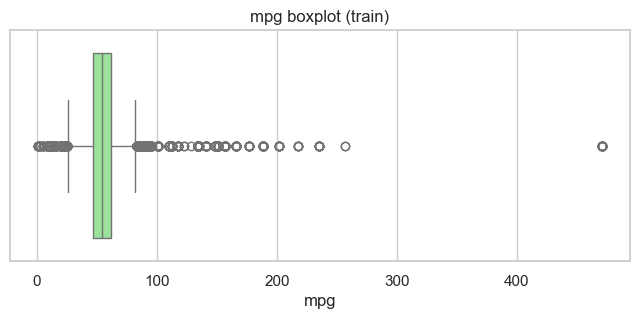

In [951]:
plt.figure(figsize=(8,3))
sns.boxplot(x=train['mpg'], color='lightgreen')
plt.title('mpg boxplot (train)')
plt.xlabel('mpg')
plt.show()

In [952]:
Q1 = train['mpg'].quantile(0.25)
Q3 = train['mpg'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Q1 = {Q1:.2f}, Q3 = {Q3:.2f}, IQR = {IQR:.2f}")
print(f"Outliers below: {lower_bound:.2f}")
print(f"Outliers above: {upper_bound:.2f}")


Q1 = 47.10, Q3 = 61.40, IQR = 14.30
Outliers below: 25.65
Outliers above: 82.85


Here, the previously mentioned changes (setting the minimum to 10 nad the maximum to 200) were made.
j!!! ustificar melhor

In [ ]:

# Apply the correction
train.loc[train['mpg'] < 10, 'mpg'] = 10
# Capar valores de mpg acima de 200
train.loc[train['mpg'] > 200, 'mpg'] = 200



## 2.2.8. `engineSize` column

We set the negative values to their absolute and replaced missing values with the median value, because of the existance of outliers. 

In [ ]:
# engine size
train['engineSize'] = train['engineSize'].abs()
train['engineSize'].fillna(train['engineSize'].median())



In [958]:
train['engineSize'].describe()

count    72989.000000
mean         1.660251
std          0.572699
min          0.000000
25%          1.200000
50%          1.600000
75%          2.000000
max          6.600000
Name: engineSize, dtype: float64

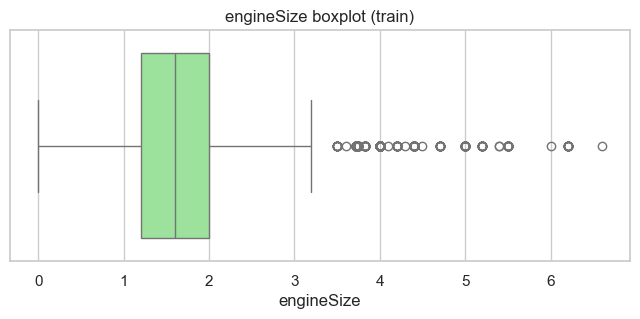

In [959]:
plt.figure(figsize=(8,3))
sns.boxplot(x=train['engineSize'], color='lightgreen')
plt.title('engineSize boxplot (train)')
plt.xlabel('engineSize')
plt.show()

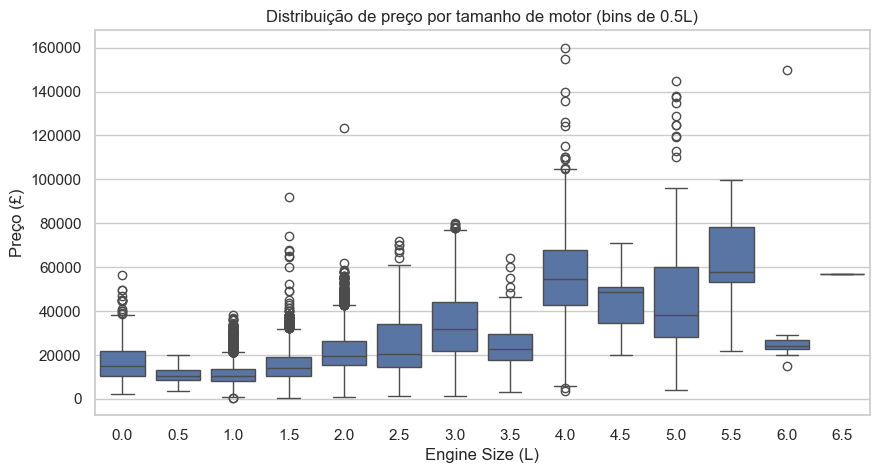

In [960]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

train['engine_bin'] = np.floor(train['engineSize'] / 0.5) * 0.5

plt.figure(figsize=(10,5))
sns.boxplot(x='engine_bin', y='price', data=train)
plt.title('Distribuição de preço por tamanho de motor (bins de 0.5L)')
plt.xlabel('Engine Size (L)')
plt.ylabel('Preço (£)')
plt.show()


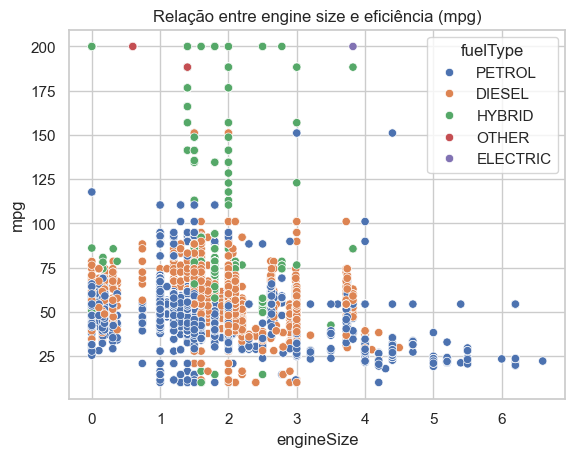

In [961]:
sns.scatterplot(x='engineSize', y='mpg', hue='fuelType', data=train)
plt.title('Relação entre engine size e eficiência (mpg)')
plt.show()


In this section we will analyse
\[
\begin{aligned}
\text{year} &\in [1900, 2020] \\[6pt]
\text{mileage} &\geq 0 \\[6pt]
\text{tax} &\geq 0 \\[6pt]
\text{mpg} &> 0 \\[6pt]
\text{engineSize} &> 0 \\[6pt]
\text{paintQuality\%} &\in [0, 100] \\[6pt]
\text{previousOwners} &\in \mathbb{N}_0 = \{0, 1, 2, \dots\} \\[6pt]
\text{hasDamage} &\in \{0, 1\}
\end{aligned}
\]

TAMANHO DO MOTOR 0 ????

verificar se year tem valores normais